 # Analisi delle comunità della rete Immigrazione 2023
 In questo capitolo, procederemo con l'analisi delle comunità A e B della rete. In particolare confronteremo le metriche di centralità, defininendo le proprietà topologiche dei due gruppi.

 ## Studio delle distibuzioni di centralita per A e B
 Abbiamo calcolato la distibuzione delle misure di centralità della rete, evidenziando le differenze tra le due comunità.
 Le misure (ad eccezione della coreness) sono state normalizzate, come di seguito.
Le misure calcolate sono le seguenti e ci permettono di rispondere alle relative domande:
- L'**eigenvector centrality** misura l'importanza del nodo in relazione all'importanza dei nodi a cui è connesso; è definita dalla formula ricorsiva:
$$ x_{i} = {1 \over \lambda} \sum_{j}A_{ij} x_j $$
normalizzata come $ x_i^{norm} = {x_i \over \max_j(x_j)} $,
 - La **coreness** calcola la scomposizione in $k_{\text{core}}$, dove il $k_{\text{core}}$ è il sottografo massimale in cui tutti i nodi hanno grado interno maggiore o uguale a $k$.
 $$ \text{coreness}(v) = \max\{k | v \in k_{\text{core}}\} $$

dove $x_i$ è la centralità del nodo $i$ e $A_{ij}$ è la matrice di adiacenza del grafo. 

*Qual è la struttura gerarchica della rete? E' simmetrica nelle due comunità? E' possibile identificare un core di nodi più densamente connessi?*

 - La **closeness centrality** misura quanto un nodo sia "vicino" agli altri nodi del grafo:
 $$ \text{closeness}(v) = {(N-1)\over \sum_{u\neq v}d(u,v)}$$
 dove $N$ è il numero di nodi e $d(u,v)$ è lo shortest path tra i nodi $u$ e $v$.
 - La **betweenness centrality** misura quante volte un nodo si trova sul cammino minimo tra tutte le possibili coppie di altri nodi:
 $$\text{betweenness}(v) = {2 \over (N-1)(N-2)}\sum_{u\neq v, k \neq v}{\sigma_{uk}(v) \over \sigma_{uk}}$$
 dove $\sigma_{uk}$ è il numero di shortest paths tra il nodo $u$ e $k$, mentre $\sigma_{uk}(v)$ è il numero di shortest paths che passano per il nodo $v$. La normalizzazione tiene conto di tutte le possibili coppie non ordinate $(u, v)$. Ci permette di studiare come sono dsitribuiti i nodi fondamentali per la connessione dell'intera rete.

*Come si presenta la struttura geometrica della rete? Ci sono nodi fondamentali per il flusso di informazione all'interno della rete e tra le due comunità?*

In [ ]:
from utils import *
from visualization_utils import *
import matplotlib.pyplot as plt
import numpy as np
import igraph as ig
import pandas as pd

: 

In [2]:
graph_path = DATA_DIR + 'Centrality/Centrality_immigration_23.graphml'
G = load_graph(graph_path)

c:\Users\maria\Desktop\Analisi e visualizzazione reti complesse\AVRC_FinnishTwittersphereProject\Code\utils.py:25: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


Abbiamo realizzato due istogrammi relativi ad A e B, per ogni centralità. 
Ogni istogramma misura il numero di nodi della comunità che presentano uno specifico valore della metrica calcolata sull'intera rete.

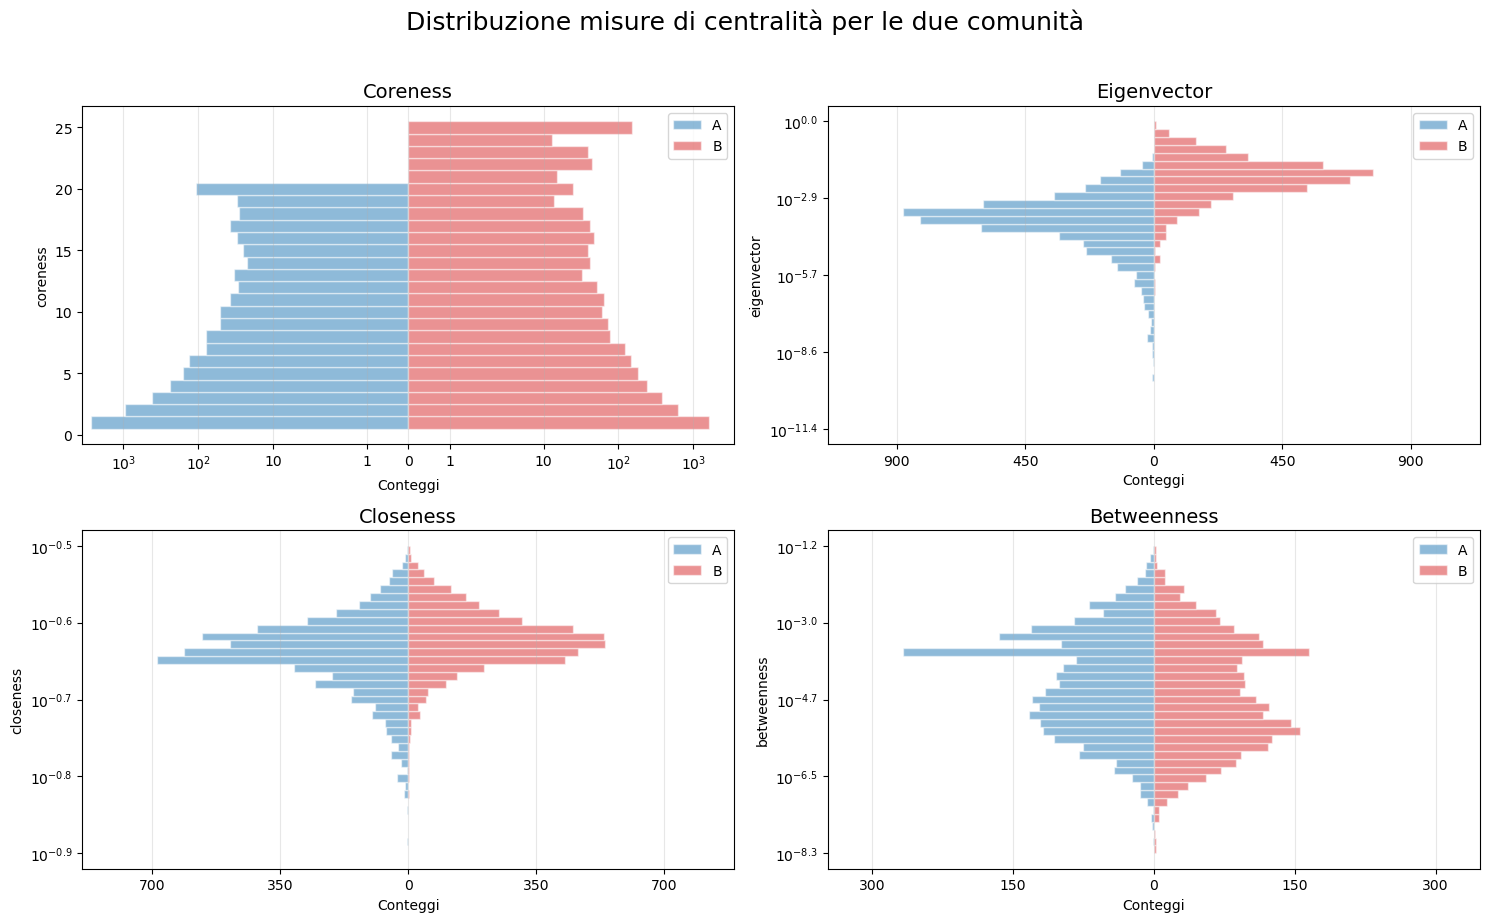

In [ ]:
def plot_centralities(G: ig.Graph, savefile=''):
    ''' Calcola le misure di centralità sull'intera rete e poi realizza un istogramma con i conteggi divisi per comunità
    '''
    metrics = ['coreness', 'eigenvector', 'closeness', 'betweenness']
    fig, axes = plt.subplots(2, 2, figsize=(15,9))

    for ax, m in zip(axes.flat, metrics):
        values = np.array(G.vs[m], dtype=float)

        # Separa i due gruppi
        maskA = [group == 'A' for group in G.vs['group']]
        maskB = [group == 'B' for group in G.vs['group']]
        valuesA = np.array(values[maskA])
        valuesB = np.array(values[maskB])

        # Rimuovi eventuali zeri (per logaritmo)
        valuesA = valuesA[valuesA > 0]
        valuesB = valuesB[valuesB > 0]

        if m == 'coreness':
            # Coreness è intera: usiamo i valori direttamente come bin edges
            min_val = min(valuesA.min(), valuesB.min())
            max_val = max(valuesA.max(), valuesB.max())
            bins = np.arange(min_val, max_val + 2) - 0.5  # centri sugli interi
            # Calcola istogrammi 
            histA, edgesA = np.histogram(valuesA, bins=bins, density=False)
            histB, edgesB = np.histogram(valuesB, bins=bins, density=False)
            bin_centers = (bins[:-1] + bins[1:]) / 2
            bin_widths = np.diff(bins)
            ylabel = 'coreness'
            # Non trasformiamo l'asse y
        else:
            # Trasformazione logaritmica per le altre metriche
            logA = np.log10(valuesA)
            logB = np.log10(valuesB)
            all_log = np.concatenate([logA, logB])
            bins = np.linspace(all_log.min(), all_log.max(), 40)
            histA, edgesA  = np.histogram(logA, bins=bins, density=False)
            histB, edgesB = np.histogram(logB, bins=bins, density=False)
            bin_centers = (bins[:-1] + bins[1:]) / 2
            bin_widths = np.diff(bins)
            ylabel = m
        
        # Istogrammi specchiati: A a sinistra (larghezza negativa), B a destra (positiva)
        ax.barh(bin_centers, width=-histA, height=bin_widths,
                color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
        ax.barh(bin_centers, width=histB, height=bin_widths,
                color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
    
        '''print('MAX of', m)
        print('A:   ', 10**(bin_centers[histA.argmax()]), '+-', 10**(edgesA[histA.argmax()+1]) - 10**(edgesA[histA.argmax()]))
        print('B:   ', 10**(bin_centers[histB.argmax()]), '+-', 10**(edgesB[histB.argmax()+1]) - 10**(edgesB[histB.argmax()]))'''

        # Imposta l'asse x in modo simmetrico
        max_density = max(histA.max(), histB.max()) * 1.3
        ax.set_xlim(-max_density, max_density)
        
        ax.set_xlabel('Conteggi')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3, axis='x')   # solo griglie verticali
        

        # Personalizza le etichette dell'asse y per le metriche logaritmiche
        if m != 'coreness':
            # Mostra alcune etichette in scala originale
            yticks_log = np.linspace(bins.min(), bins.max(), 5)
            ax.set_yticks(yticks_log)
            ax.set_yticklabels([f'$10^{{{v:.1f}}}$' for v in yticks_log])
            hist_max = max(((histA.max()+99) // 100)*100, ((histB.max()+99)//100)*100)
            xticks = np.linspace(-hist_max, hist_max, 5)
            ax.set_xticks(xticks)
            ax.set_xticklabels(map(int,abs(xticks)))
        else:
            # Per coreness, mostra valori interi
            ax.set_yticks(np.arange(0, max_val+1, 5))
            ax.set_xscale('symlog')
            ticks_exp = [-1000, -100, -10, -1, 0, 1, 10, 100, 1000]
            ax.set_xticks(ticks_exp)
            ax.set_xticklabels(['$10^3$', '$10^2$', '10', '1', '0', '1', '10', '$10^2$', '$10^3$'])

        ax.set_title(m.capitalize(), fontsize=FONTSIZE_TITLE)    
        ax.tick_params(direction='out')
        ax.legend()

    
    fig.suptitle("Distribuzione misure di centralità per le due comunità", fontsize=FONTSIZE_SUPTITLE, y=1.02)
    plt.tight_layout()
    if savefile:
        plt.savefig(savefile)
    else:
        plt.show()
    plt.close(fig)


In [ ]:
plot_centralities(G)